# Notebook 5 — Reconstrucción sparse mediante ISTA y FISTA

## Objetivo

En este notebook se estudia la reconstrucción de señales sparse a partir de medidas lineales incompletas mediante métodos de optimización con regularización \(\ell_1\).

Los objetivos principales son los siguientes:

1. formular el problema de reconstrucción sparse como un problema de optimización regularizada;
2. implementar el algoritmo ISTA;
3. implementar el algoritmo FISTA como versión acelerada de ISTA;
4. comparar ambos métodos en términos de reconstrucción y convergencia.

Este notebook resulta fundamental dentro del TFG porque completa el bloque algorítmico de *Compressed Sensing* y permite contrastar los métodos voraces, como OMP, con métodos basados en optimización proximal.

In [2]:
"""la reconstrucción sparse no solo puede hacerse con métodos voraces, sino también con métodos de optimización convexa/proximal."""
"""Tengo que pedirle a chat que me escriba bien aqui la ecuacion de la siguiente celda que no la sé mostrar bien"""

'Tengo que pedirle a chat que me escriba bien aqui la ecuacion de la siguiente celda que no la sé mostrar bien'

## Qué se está haciendo realmente en este notebook

En lugar de buscar directamente una solución sparse mediante selección iterativa de columnas, como ocurría con OMP, aquí se plantea el problema como una minimización de la forma

$$
\min_x \frac{1}{2}\|Ax-y\|_2^2 + \lambda \|x\|_1.
$$

El primer término fuerza que la solución sea consistente con las medidas observadas, mientras que el segundo favorece la sparsidad. Los algoritmos ISTA y FISTA permiten resolver este problema mediante iteraciones sucesivas que combinan pasos de gradiente y operaciones de umbralización suave.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Configuración gráfica
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

## 1. Funciones auxiliares

Se definen funciones para:

- generar señales sparse sintéticas;
- construir matrices de medida aleatorias;
- calcular métricas de error;
- aplicar el operador de umbralización suave.

In [4]:
def generate_sparse_signal(N, k, seed=None):
    """
    Genera una señal k-sparse de dimensión N.
    """
    rng = np.random.default_rng(seed)
    x = np.zeros(N)

    support = rng.choice(N, size=k, replace=False)
    values = rng.normal(loc=0.0, scale=1.0, size=k)

    x[support] = values
    return x, np.sort(support)


def generate_measurement_matrix(m, N, seed=None):
    """
    Genera una matriz gaussiana aleatoria (m, N) y normaliza sus columnas.
    """
    rng = np.random.default_rng(seed)
    A = rng.normal(size=(m, N))

    norms = np.linalg.norm(A, axis=0)
    norms[norms == 0] = 1.0
    A = A / norms

    return A


def mse(x, x_hat):
    return np.mean((x - x_hat) ** 2)


def relative_error(x, x_hat):
    denom = np.linalg.norm(x)
    if denom == 0:
        return 0.0
    return np.linalg.norm(x - x_hat) / denom


def soft_threshold(z, tau):
    """
    Operador de umbralización suave:
    S_tau(z) = sign(z) * max(|z| - tau, 0)
    """
    return np.sign(z) * np.maximum(np.abs(z) - tau, 0.0)

## 2. Función objetivo

Para seguir la convergencia de los algoritmos se define la función objetivo

$$
F(x) = \frac{1}{2}\|Ax-y\|_2^2 + \lambda \|x\|_1
$$

Esto permitirá estudiar no solo la calidad final de la reconstrucción, sino también cómo evoluciona cada método a lo largo de las iteraciones.

In [5]:
def objective(A, y, x, lam):
    return 0.5 * np.linalg.norm(A @ x - y) ** 2 + lam * np.linalg.norm(x, ord=1)

## 3. Implementación de ISTA

ISTA (*Iterative Shrinkage-Thresholding Algorithm*) combina dos operaciones en cada iteración:

1. un paso de gradiente sobre el término cuadrático 
$$
 (\frac{1}{2}\|Ax-y\|_2^2) 
$$
;
2. una umbralización suave que promueve sparsidad.

De este modo, el algoritmo alterna entre ajustar la solución a los datos y forzar una representación más sparse.

In [6]:
def ista(A, y, lam, step_size, max_iter=200, x0=None):
    """
    Implementación de ISTA para
    min_x 0.5 ||Ax - y||_2^2 + lam ||x||_1
    """
    m, N = A.shape
    x = np.zeros(N) if x0 is None else x0.copy()

    history_obj = []
    history_rel_change = []

    for _ in range(max_iter):
        grad = A.T @ (A @ x - y)
        x_new = soft_threshold(x - step_size * grad, lam * step_size)

        history_obj.append(objective(A, y, x_new, lam))
        history_rel_change.append(np.linalg.norm(x_new - x))

        x = x_new

    return x, history_obj, history_rel_change

## ¿Cómo funciona realmente ISTA?

El algoritmo **ISTA** (*Iterative Shrinkage-Thresholding Algorithm*) se utiliza para reconstruir una señal sparse a partir de medidas incompletas. El problema que intenta resolver es el siguiente:

$$
\min_x \; \frac{1}{2}\|Ax-y\|_2^2 + \lambda \|x\|_1.
$$

Aquí, \(x\) es la señal que queremos reconstruir, \(A\) es la matriz de medida y \(y\) es el vector de observaciones. El primer término,

$$
\frac{1}{2}\|Ax-y\|_2^2,
$$

mide cuánto se parece la reconstrucción propuesta a las medidas reales. Si este término es pequeño, significa que la señal reconstruida explica bien los datos observados. El segundo término,

$$
\lambda \|x\|_1,
$$

penaliza soluciones con muchos coeficientes no nulos y favorece, por tanto, señales sparse. El parámetro \(\lambda\) regula el equilibrio entre ambos objetivos: ajuste a los datos y simplicidad de la solución.

La dificultad del problema está en que contiene dos partes de naturaleza distinta. Por un lado, el término cuadrático es suave y derivable, así que se puede minimizar mediante técnicas de gradiente. Por otro lado, la norma \(\ell_1\) no es derivable en el origen, así que no puede tratarse directamente con un gradiente ordinario. La idea de ISTA consiste precisamente en separar ambos papeles y tratarlos de forma distinta en cada iteración.

En cada paso, ISTA hace primero un **paso de gradiente** sobre el término cuadrático. Si solo quisiéramos minimizar

$$
\frac{1}{2}\|Ax-y\|_2^2,
$$

entonces actualizaríamos la solución moviéndonos en dirección opuesta a su gradiente:

$$
x^{(t+\frac{1}{2})} = x^{(t)} - \tau A^T(Ax^{(t)} - y),
$$

donde \(\tau\) es el tamaño de paso. Este paso intenta mejorar el ajuste a las medidas, es decir, hacer que \(Ax\) se acerque más a \(y\).

Sin embargo, si aplicáramos solo este paso de gradiente, la solución tendería a ajustarse a los datos pero no necesariamente sería sparse. Por eso, después del paso de gradiente, ISTA aplica una segunda operación: la **umbralización suave** (*soft-thresholding*). Esta operación actúa componente a componente y tiene la forma

$$
S_\theta(z_i) = \operatorname{sign}(z_i)\max(|z_i|-\theta, 0).
$$

Lo que hace esta operación es muy intuitivo: reduce la magnitud de todos los coeficientes y, además, lleva exactamente a cero a los que son suficientemente pequeños. Por tanto, elimina coeficientes poco relevantes y mantiene solo los más importantes. Esa es la parte del algoritmo que introduce sparsidad.

Juntando ambas ideas, una iteración completa de ISTA puede escribirse como

$$
x^{(t+1)} = S_{\lambda \tau}\left(x^{(t)} - \tau A^T(Ax^{(t)} - y)\right).
$$

Esta fórmula resume perfectamente la lógica del algoritmo. Primero se corrige la estimación actual para explicar mejor los datos; después se simplifica esa corrección forzando una representación más sparse. Así, ISTA alterna constantemente entre **ajustar** y **simplificar**.

Desde un punto de vista intuitivo, se puede pensar que ISTA intenta responder a la siguiente pregunta en cada iteración: *¿cómo puedo modificar mi reconstrucción para que explique mejor las medidas observadas sin perder la estructura sparse que espero en la señal?* El paso de gradiente responde a la parte de ajuste, y la umbralización responde a la parte de sparsidad.

La razón por la que ISTA funciona es que el problema original tiene una estructura muy favorable: es la suma de un término convexo y suave, más un término convexo pero no suave. En este contexto, los métodos proximales permiten tratar cada parte de la forma más adecuada. El gradiente explota la suavidad del término cuadrático, mientras que la umbralización suave es precisamente el operador proximal asociado a la norma \(\ell_1\). Por eso ISTA no es un truco heurístico, sino un método matemáticamente bien fundamentado.

Además, si el tamaño de paso \(\tau\) se elige de manera adecuada, típicamente

$$
\tau \leq \frac{1}{L},
$$

donde \(L\) es la constante de Lipschitz del gradiente del término cuadrático, entonces la sucesión generada por ISTA converge hacia una solución del problema. En la práctica, esto significa que el algoritmo va refinando progresivamente la reconstrucción hasta estabilizarse en una solución que equilibra ajuste y sparsidad.

En resumen, ISTA funciona porque combina dos mecanismos complementarios. El primero intenta explicar correctamente los datos observados. El segundo elimina la complejidad innecesaria y favorece soluciones sparse. Gracias a esta combinación, el algoritmo permite reconstruir señales a partir de medidas incompletas cuando se supone que la señal verdadera tiene una estructura dispersa. Esa es precisamente la razón por la que ISTA ocupa un lugar central dentro de *Compressed Sensing*.

In [7]:
""" 
PARA ENTERARME YO BIEN RESUMIDA Y CLARAMENTE:
ISTA hace dos cosas una y otra vez:

se mueve hacia una solución que explique mejor los datos,
y luego “recorta” los coeficientes pequeños para forzar sparsidad.
"""


' \nPARA ENTERARME YO BIEN RESUMIDA Y CLARAMENTE:\nISTA hace dos cosas una y otra vez:\n\nse mueve hacia una solución que explique mejor los datos,\ny luego “recorta” los coeficientes pequeños para forzar sparsidad.\n'

## 4. Implementación de FISTA

FISTA (*Fast Iterative Shrinkage-Thresholding Algorithm*) introduce una aceleración sobre ISTA. Mantiene la misma estructura básica de paso de gradiente más umbralización, pero incorpora una variable auxiliar y un parámetro de extrapolación que mejoran la velocidad de convergencia.

Esto hace que, en muchos casos, FISTA alcance soluciones de calidad comparable en menos iteraciones que ISTA.

In [8]:
def fista(A, y, lam, step_size, max_iter=200, x0=None):
    """
    Implementación de FISTA para
    min_x 0.5 ||Ax - y||_2^2 + lam ||x||_1
    """
    m, N = A.shape
    x = np.zeros(N) if x0 is None else x0.copy()
    z = x.copy()
    t = 1.0

    history_obj = []
    history_rel_change = []

    for _ in range(max_iter):
        grad = A.T @ (A @ z - y)
        x_new = soft_threshold(z - step_size * grad, lam * step_size)

        t_new = (1 + np.sqrt(1 + 4 * t**2)) / 2
        z = x_new + ((t - 1) / t_new) * (x_new - x)

        history_obj.append(objective(A, y, x_new, lam))
        history_rel_change.append(np.linalg.norm(x_new - x))

        x = x_new
        t = t_new

    return x, history_obj, history_rel_change

## ¿Cómo funciona realmente FISTA?

El algoritmo **FISTA** (*Fast Iterative Shrinkage-Thresholding Algorithm*) se utiliza para resolver el mismo problema que ISTA, es decir, la reconstrucción sparse a partir de medidas incompletas mediante la minimización de una función de la forma

$$
\min_x \; \frac{1}{2}\|Ax-y\|_2^2 + \lambda \|x\|_1.
$$

En este problema, el término

$$
\frac{1}{2}\|Ax-y\|_2^2
$$

mide el ajuste a los datos observados, mientras que el término

$$
\lambda \|x\|_1
$$

favorece la sparsidad de la solución. Por tanto, igual que ocurría con ISTA, el objetivo es encontrar una señal que explique bien las medidas y que al mismo tiempo tenga pocos coeficientes relevantes.

La idea básica de FISTA es muy parecida a la de ISTA: en cada iteración se combina un paso de gradiente sobre el término cuadrático con una operación de umbralización suave que promueve sparsidad. Sin embargo, FISTA introduce una mejora importante: en lugar de actualizar la solución usando solo la iteración actual, incorpora también información de las iteraciones anteriores mediante un mecanismo de **extrapolación** o **aceleración**.

En ISTA, la actualización tiene la forma

$$
x^{(t+1)} = S_{\lambda \tau}\left(x^{(t)} - \tau A^T(Ax^{(t)} - y)\right),
$$

donde \(S_{\lambda \tau}\) es el operador de umbralización suave y \(\tau\) es el tamaño de paso. Es decir, ISTA calcula la nueva iteración únicamente a partir del valor actual \(x^{(t)}\).

FISTA modifica esta idea introduciendo una variable auxiliar, que normalmente se denota por \(z^{(t)}\). En lugar de dar el paso de gradiente desde \(x^{(t)}\), lo hace desde un punto extrapolado \(z^{(t)}\), que combina información de las iteraciones previas. La actualización principal toma la forma

$$
x^{(t+1)} = S_{\lambda \tau}\left(z^{(t)} - \tau A^T(Az^{(t)} - y)\right).
$$

Después, se actualiza el parámetro de aceleración \(t^{(t)}\) mediante

$$
t^{(t+1)} = \frac{1 + \sqrt{1 + 4(t^{(t)})^2}}{2},
$$

y se define el nuevo punto extrapolado como

$$
z^{(t+1)} = x^{(t+1)} + \frac{t^{(t)} - 1}{t^{(t+1)}}\left(x^{(t+1)} - x^{(t)}\right).
$$

Este paso adicional es el que introduce la aceleración. La idea intuitiva es que FISTA no se limita a avanzar de forma local, como hace ISTA, sino que aprovecha la “inercia” de las iteraciones previas para moverse más rápido hacia una buena solución. En cierto sentido, el algoritmo trata de anticipar hacia dónde se está desplazando la secuencia y utiliza esa tendencia para ganar velocidad.

Desde un punto de vista intuitivo, FISTA puede entenderse como un método que sigue haciendo el mismo proceso de **ajustar y simplificar** que ISTA, pero con una estrategia de movimiento más inteligente. Igual que en ISTA, en cada iteración hay dos objetivos:
- mejorar el ajuste a los datos;
- forzar una estructura sparse.

La diferencia es que FISTA añade una tercera idea: **acelerar el avance aprovechando la historia de las iteraciones anteriores**.

La razón por la que FISTA suele funcionar mejor que ISTA es que esta extrapolación mejora significativamente la velocidad de convergencia. Mientras que ISTA converge con una tasa del orden de \(O(1/k)\) en términos del valor de la función objetivo, FISTA alcanza una tasa del orden de \(O(1/k^2)\). Esto significa que, para un mismo número de iteraciones, FISTA suele acercarse mucho más rápido a una solución de buena calidad.

Aun así, es importante entender que FISTA no cambia el problema que se está resolviendo. El modelo matemático sigue siendo el mismo, la función objetivo sigue siendo la misma y el operador de umbralización suave sigue desempeñando el mismo papel. La diferencia no está en **qué** problema se resuelve, sino en **cómo de eficientemente** se llega a la solución.

En resumen, FISTA funciona igual que ISTA en su estructura básica: combina un paso de gradiente con una operación proximal que favorece sparsidad. Sin embargo, introduce una extrapolación basada en las iteraciones anteriores que acelera notablemente la convergencia. Por eso es especialmente útil en *Compressed Sensing*: permite resolver problemas de reconstrucción sparse con el mismo fundamento matemático que ISTA, pero alcanzando una solución estable en menos iteraciones.

## 5. Parámetros del problema

Se genera una señal sparse sintética, se construye una matriz de medidas aleatoria y se observa el vector de medidas correspondiente. A continuación, se aplica ISTA y FISTA sobre el mismo problema para comparar su comportamiento.

In [9]:
# Parámetros del problema
N = 128
m = 40
k = 8
lam = 0.05
max_iter = 200

# Señal sparse y medidas
x_true, support_true = generate_sparse_signal(N, k, seed=1)
A = generate_measurement_matrix(m, N, seed=2)
y = A @ x_true

# Tamaño de paso: 1 / L, donde L = ||A^T A||_2
L = np.linalg.norm(A, ord=2) ** 2
step_size = 1.0 / L

print(f"N = {N}")
print(f"m = {m}")
print(f"k = {k}")
print(f"lambda = {lam}")
print(f"L = {L:.6f}")
print(f"step_size = {step_size:.6f}")

N = 128
m = 40
k = 8
lambda = 0.05
L = 7.324167
step_size = 0.136534


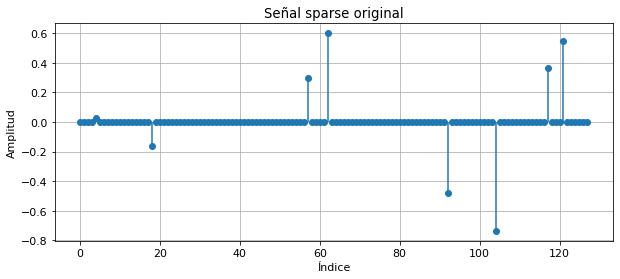

In [10]:
plt.figure()
plt.stem(np.arange(N), x_true, basefmt=" ")
plt.title("Señal sparse original")
plt.xlabel("Índice")
plt.ylabel("Amplitud")
plt.show()

### Comentario

La señal original tiene dimensión 128, pero solo 8 entradas no nulas. El problema consiste en recuperarla a partir de 40 medidas lineales, es decir, con una cantidad de información inferior a la dimensión total del problema.

In [12]:
x_ista, obj_ista, change_ista = ista(A, y, lam, step_size, max_iter=max_iter)
x_fista, obj_fista, change_fista = fista(A, y, lam, step_size, max_iter=max_iter)

mse_ista = mse(x_true, x_ista)
rel_ista = relative_error(x_true, x_ista)

mse_fista = mse(x_true, x_fista)
rel_fista = relative_error(x_true, x_fista)

print("Resultados ISTA")
print(f"MSE: {mse_ista:.8f}")
print(f"Error relativo: {rel_ista:.8f}")

print("\nResultados FISTA")
print(f"MSE: {mse_fista:.8f}")
print(f"Error relativo: {rel_fista:.8f}")

Resultados ISTA
MSE: 0.00025002
Error relativo: 0.13805566

Resultados FISTA
MSE: 0.00018410
Error relativo: 0.11846630


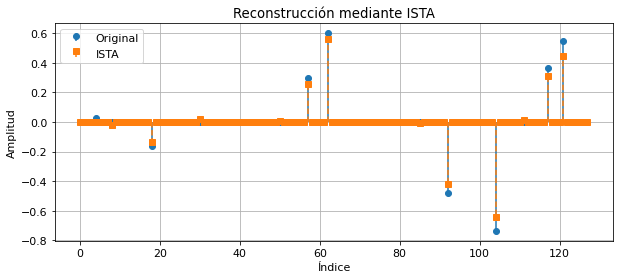

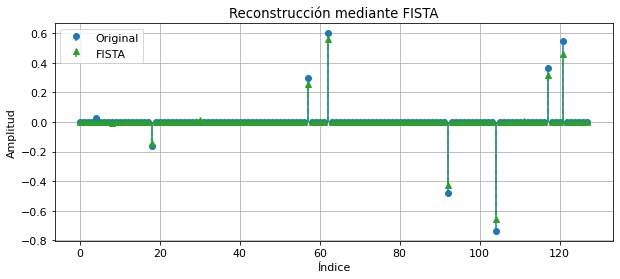

In [13]:
plt.figure()
plt.stem(np.arange(N), x_true, linefmt="C0-", markerfmt="C0o", basefmt=" ", label="Original")
plt.stem(np.arange(N), x_ista, linefmt="C1--", markerfmt="C1s", basefmt=" ", label="ISTA")
plt.title("Reconstrucción mediante ISTA")
plt.xlabel("Índice")
plt.ylabel("Amplitud")
plt.legend()
plt.show()

plt.figure()
plt.stem(np.arange(N), x_true, linefmt="C0-", markerfmt="C0o", basefmt=" ", label="Original")
plt.stem(np.arange(N), x_fista, linefmt="C2--", markerfmt="C2^", basefmt=" ", label="FISTA")
plt.title("Reconstrucción mediante FISTA")
plt.xlabel("Índice")
plt.ylabel("Amplitud")
plt.legend()
plt.show()

### Interpretación

Ambos algoritmos producen una reconstrucción sparse aproximada de la señal original. La diferencia principal entre ellos no suele residir únicamente en la solución final, sino en la rapidez con la que alcanzan una buena aproximación. Por ello, la comparación de convergencia resulta especialmente relevante.

## 6. Comparación de convergencia

Se estudia ahora la evolución de la función objetivo y del cambio entre iteraciones para ISTA y FISTA.

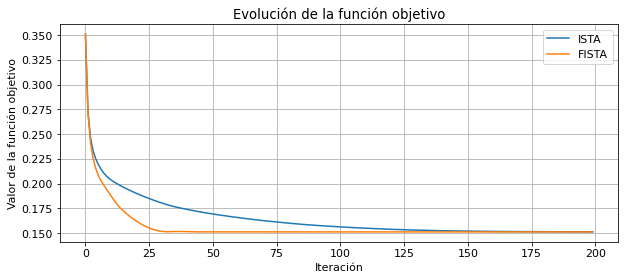

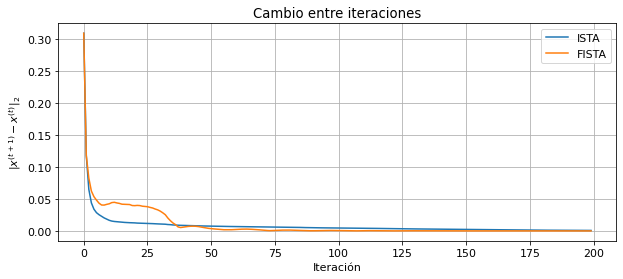

' #TODO: MIRAR E INTERPRETAR LA SEGUNDA GRAFICA'

In [15]:
plt.figure()
plt.plot(obj_ista, label="ISTA")
plt.plot(obj_fista, label="FISTA")
plt.title("Evolución de la función objetivo")
plt.xlabel("Iteración")
plt.ylabel("Valor de la función objetivo")
plt.legend()
plt.show()

plt.figure()
plt.plot(change_ista, label="ISTA")
plt.plot(change_fista, label="FISTA")
plt.title("Cambio entre iteraciones")
plt.xlabel("Iteración")
plt.ylabel(r"$\|x^{(t+1)} - x^{(t)}\|_2$")
plt.legend()
plt.show()

""" #TODO: MIRAR E INTERPRETAR LA SEGUNDA GRAFICA"""

### Interpretación

La gráfica de la función objetivo permite observar la rapidez con la que cada algoritmo se acerca a una solución estable. Habitualmente, FISTA presenta una disminución más rápida que ISTA, lo que refleja su carácter acelerado. La evolución del cambio entre iteraciones muestra además cómo ambas sucesiones se van estabilizando progresivamente.

## 7. Influencia del parámetro de regularización \(\lambda\)

El parámetro \(\lambda\) controla el equilibrio entre fidelidad a los datos y sparsidad de la solución. Si \(\lambda\) es pequeño, la solución se ajusta más a las medidas; si es grande, la penalización sparse domina con más fuerza.

Se estudia a continuación cómo cambia la reconstrucción al modificar este parámetro.

In [16]:
lambda_values = [0.01, 0.03, 0.05, 0.1, 0.2]
lambda_results = []

for lam_val in lambda_values:
    x_hat, obj_hist, _ = fista(A, y, lam_val, step_size, max_iter=max_iter)

    lambda_results.append({
        "lambda": lam_val,
        "mse": mse(x_true, x_hat),
        "relative_error": relative_error(x_true, x_hat),
        "nnz_estimated": np.sum(np.abs(x_hat) > 1e-4)
    })

df_lambda = pd.DataFrame(lambda_results)
df_lambda

,lambda,mse,relative_error,nnz_estimated
0,0.01,0.000008,0.024451,13
1,0.03,0.000069,0.072684,13
2,0.05,0.000184,0.118466,10
3,0.10,0.000734,0.236583,10
4,0.20,0.002953,0.474477,10


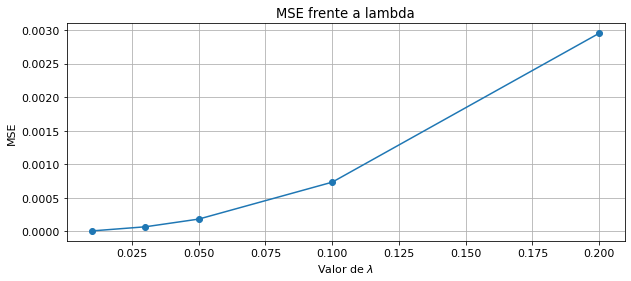

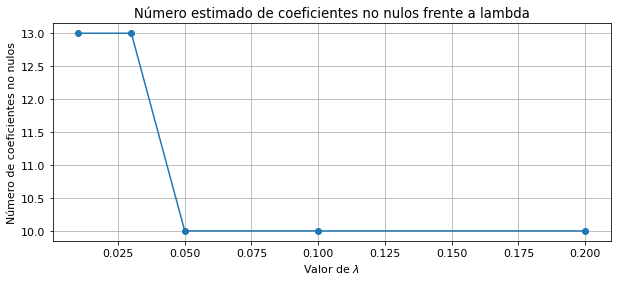

In [17]:
plt.figure()
plt.plot(df_lambda["lambda"], df_lambda["mse"], marker="o")
plt.title("MSE frente a lambda")
plt.xlabel(r"Valor de $\lambda$")
plt.ylabel("MSE")
plt.show()

plt.figure()
plt.plot(df_lambda["lambda"], df_lambda["nnz_estimated"], marker="o")
plt.title("Número estimado de coeficientes no nulos frente a lambda")
plt.xlabel(r"Valor de $\lambda$")
plt.ylabel("Número de coeficientes no nulos")
plt.show()

### Interpretación

El parámetro de regularización influye directamente sobre la estructura de la solución. Al aumentar lambda, la penalización sparse se vuelve más fuerte y la reconstrucción tiende a contener menos coeficientes significativos. Sin embargo, si lambda es excesivo, la calidad de ajuste puede deteriorarse. Por tanto, la elección de este parámetro implica un compromiso entre parsimonia y fidelidad a los datos.

## 8. Comparación final entre ISTA y FISTA

Se resume a continuación la comparación entre ambos métodos en el problema considerado.

In [20]:
summary_df = pd.DataFrame({
    "Método": ["ISTA", "FISTA"],
    "MSE": [mse_ista, mse_fista],
    "Error relativo": [rel_ista, rel_fista],
    "Valor final objetivo": [obj_ista[-1], obj_fista[-1]]
})

summary_df

,Método,MSE,Error relativo,Valor final objetivo
0,ISTA,0.000250,0.138056,0.151422
1,FISTA,0.000184,0.118466,0.151335


## 9. Conclusiones del notebook

Los experimentos realizados permiten extraer varias conclusiones:

1. el problema de reconstrucción sparse puede formularse como una minimización regularizada con norma $$(\ell_1)$$;
2. ISTA resuelve este problema mediante iteraciones de gradiente y umbralización suave;
3. FISTA introduce una aceleración que suele mejorar la velocidad de convergencia;
4. ambos métodos permiten recuperar reconstrucciones sparse aproximadas a partir de medidas incompletas;
5. el parámetro $$(\lambda)$$ desempeña un papel esencial en el equilibrio entre ajuste y sparsidad.

Este notebook completa el bloque algorítmico principal del TFG, ya que permite comparar métodos voraces y métodos de optimización dentro del marco de *Compressed Sensing*. El siguiente paso natural consiste en trasladar estas ideas al caso bidimensional de reconstrucción de imágenes.